# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

In [1]:
#!curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz

In [2]:
#!rm SUSY.csv

In [3]:
!rm SUSY.csv

In [4]:
!gunzip SUSY.csv.gz

In [3]:
ls -lh

total 4702264
-rw-r--r--@ 1 subhamkalwar  staff   389K Mar 20 17:43 Lab.7.ipynb
-rw-r--r--@ 1 subhamkalwar  staff   8.0M Mar 20 17:43 Lab.7.pdf
-rw-r--r--@ 1 subhamkalwar  staff   2.2G Mar 27 21:34 SUSY.csv


The data is provided as a comma separated file.

In [4]:
filename="SUSY.csv"
# print out the first 5 lines using unix head command
!head -5  "SUSY.csv"

0.000000000000000000e+00,9.728614687919616699e-01,6.538545489311218262e-01,1.176224589347839355e+00,1.157156467437744141e+00,-1.739873170852661133e+00,-8.743090629577636719e-01,5.677649974822998047e-01,-1.750000417232513428e-01,8.100607395172119141e-01,-2.525521218776702881e-01,1.921887040138244629e+00,8.896374106407165527e-01,4.107718467712402344e-01,1.145620822906494141e+00,1.932632088661193848e+00,9.944640994071960449e-01,1.367815494537353516e+00,4.071449860930442810e-02
1.000000000000000000e+00,1.667973041534423828e+00,6.419061869382858276e-02,-1.225171446800231934e+00,5.061022043228149414e-01,-3.389389812946319580e-01,1.672542810440063477e+00,3.475464344024658203e+00,-1.219136357307434082e+00,1.295456290245056152e-02,3.775173664093017578e+00,1.045977115631103516e+00,5.680512785911560059e-01,4.819284379482269287e-01,0.000000000000000000e+00,4.484102725982666016e-01,2.053557634353637695e-01,1.321893453598022461e+00,3.775840103626251221e-01
1.000000000000000000e+00,4.4483992457389831

## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here we look at the size of the data

In [5]:
!ls -lh

total 4702264
-rw-r--r--@ 1 subhamkalwar  staff   389K Mar 20 17:43 Lab.7.ipynb
-rw-r--r--@ 1 subhamkalwar  staff   8.0M Mar 20 17:43 Lab.7.pdf
-rw-r--r--@ 1 subhamkalwar  staff   2.2G Mar 27 21:34 SUSY.csv


We see that we have 5 million datapoints.

In [6]:
!wc -l SUSY.csv

 5000000 SUSY.csv


We create a new file of the first half million. This is sufficient for our needs in this lab:

In [7]:
!head -500000 SUSY.csv > SUSY-small.csv

In [8]:
ls -lh

total 5169120
-rw-r--r--@ 1 subhamkalwar  staff   389K Mar 20 17:43 Lab.7.ipynb
-rw-r--r--@ 1 subhamkalwar  staff   8.0M Mar 20 17:43 Lab.7.pdf
-rw-r--r--@ 1 subhamkalwar  staff   228M Mar 27 21:39 SUSY-small.csv
-rw-r--r--@ 1 subhamkalwar  staff   2.2G Mar 27 21:34 SUSY.csv


In [9]:
! wc -l SUSY-small.csv

  500000 SUSY-small.csv


Use this file for the rest of the lab to make this run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [10]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel", "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R", "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [11]:
RawNames=["l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", "l_2_eta", "l_2_phi", "MET", "MET_phi"]
FeatureNames=list(set(VarNames[1:]).difference(RawNames))

In [12]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [13]:
FeatureNames

['cos_theta_r1',
 'M_R',
 'M_TR_2',
 'S_R',
 'dPhi_r_b',
 'M_Delta_R',
 'R',
 'MET_rel',
 'axial_MET',
 'MT2']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [16]:
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype='float64', names=VarNames)

You can see the data in Jupyter by just evaluateing the dataframe:

In [17]:
df

,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
499995,0.0,0.719035,1.091879,0.291540,1.205962,-1.599117,-1.139445,0.424546,1.154849,0.637185,-0.091178,1.972156,0.697028,0.313636,0.988602,1.981573,0.744828,1.095080,0.006546
499996,1.0,0.910016,-0.364544,-0.777120,0.543648,-0.910632,-1.723707,2.864673,1.458272,2.176558,-0.590911,0.673695,1.662140,2.189362,1.195041,0.910815,1.181893,1.252362,0.826035
499997,1.0,0.842954,0.332476,-1.048564,1.347989,0.320496,-0.666358,0.450433,-0.411872,0.293407,0.630491,0.859920,0.403371,0.416258,0.591989,0.372003,0.716788,0.366991,0.265798
499998,0.0,1.370760,-1.162912,0.893499,2.118091,1.248496,-0.887211,0.164659,0.316840,0.215165,0.280418,3.087083,0.526929,0.151467,0.308067,3.098183,0.233042,0.876216,0.000593


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [18]:
df_sig=df[df.signal==1]
df_bkg=df[df.signal==0]

The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

l_1_pT


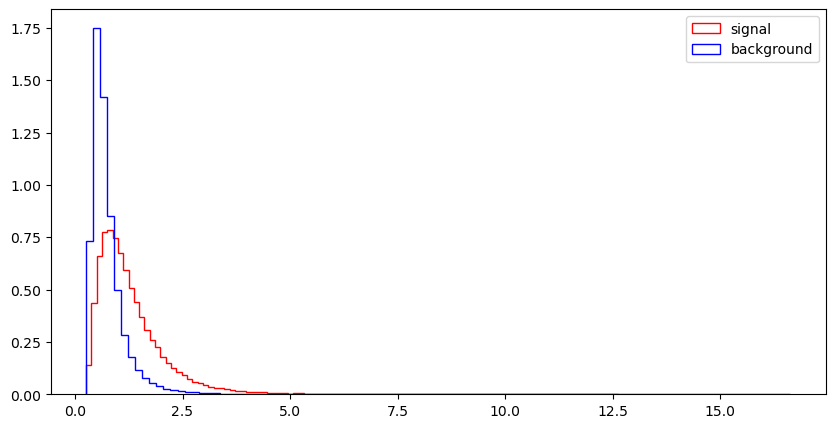

l_1_eta


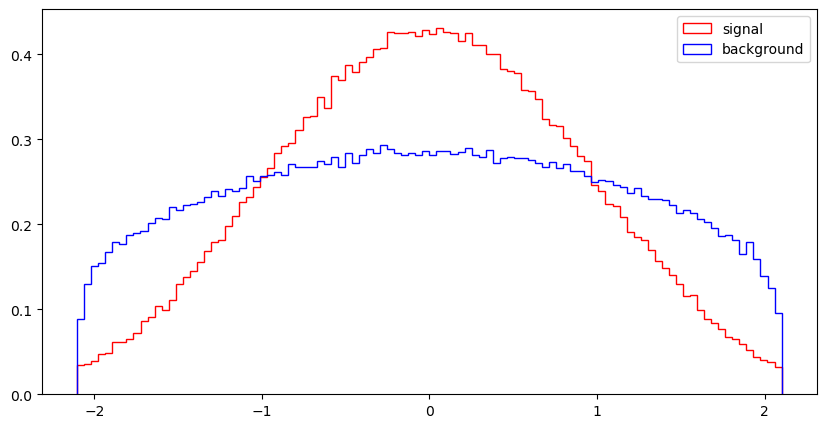

l_1_phi


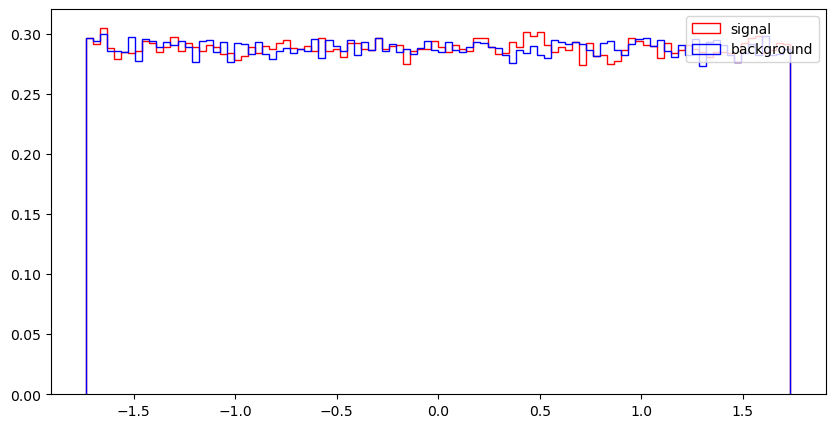

l_2_pT


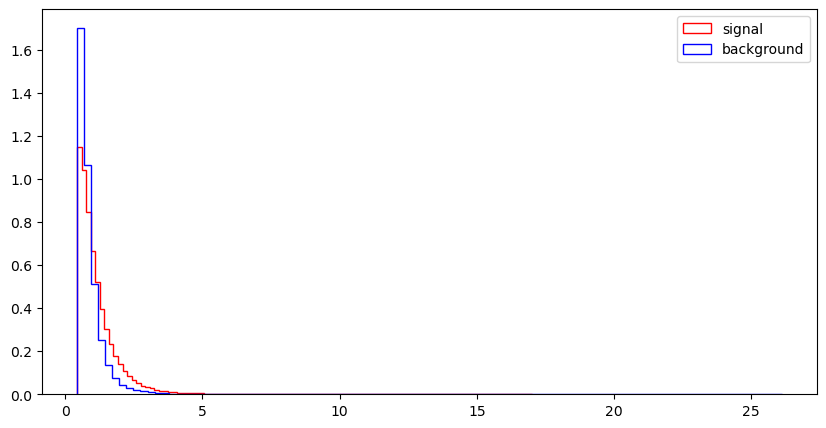

l_2_eta


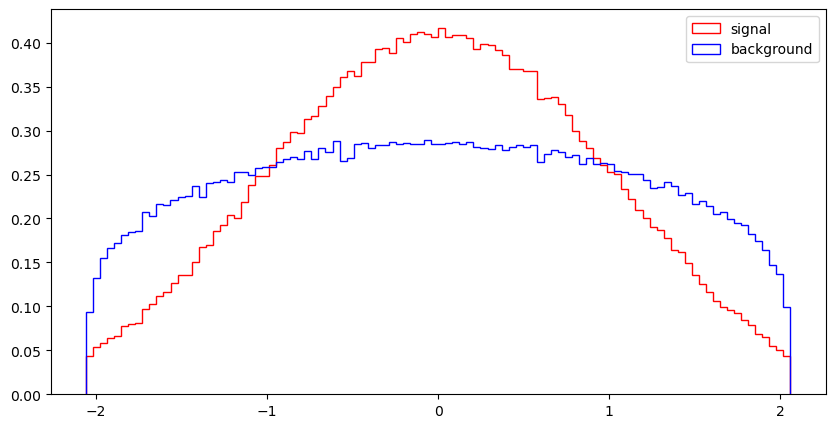

l_2_phi


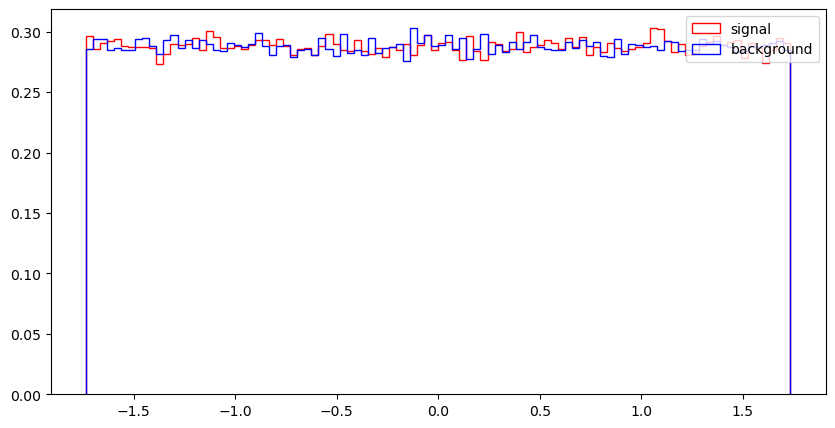

MET


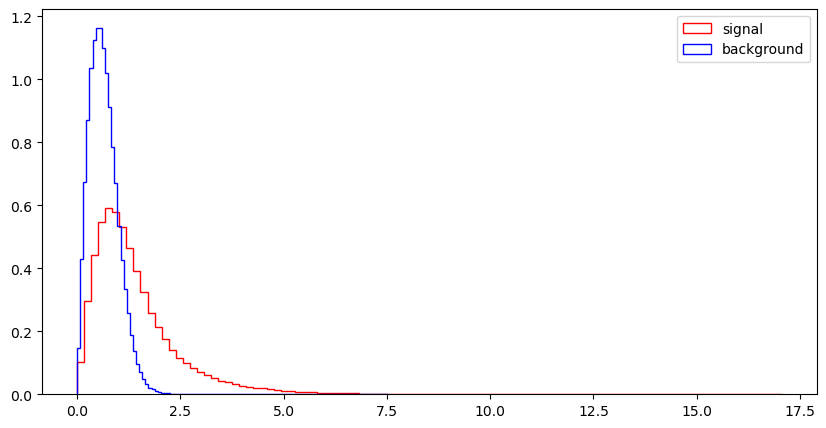

MET_phi


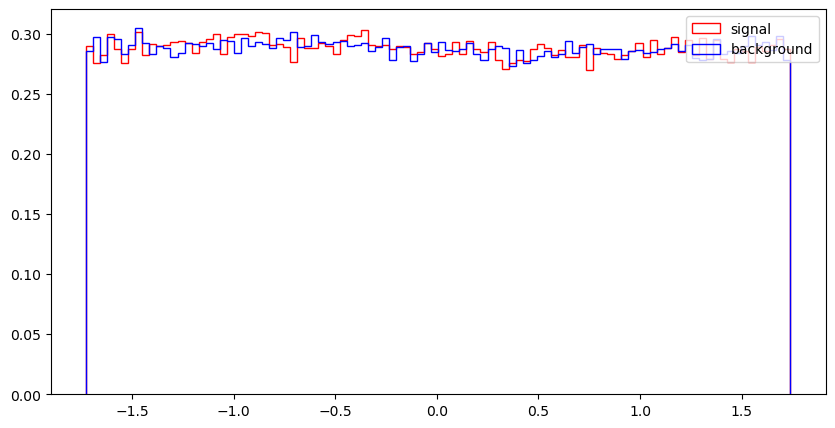

MET_rel


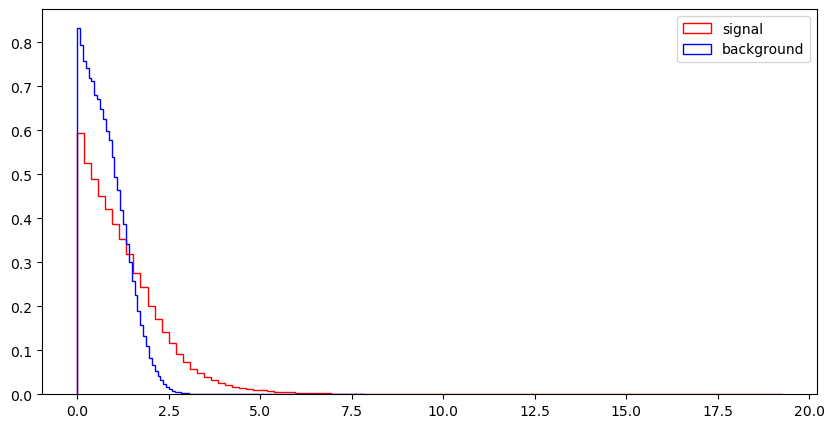

axial_MET


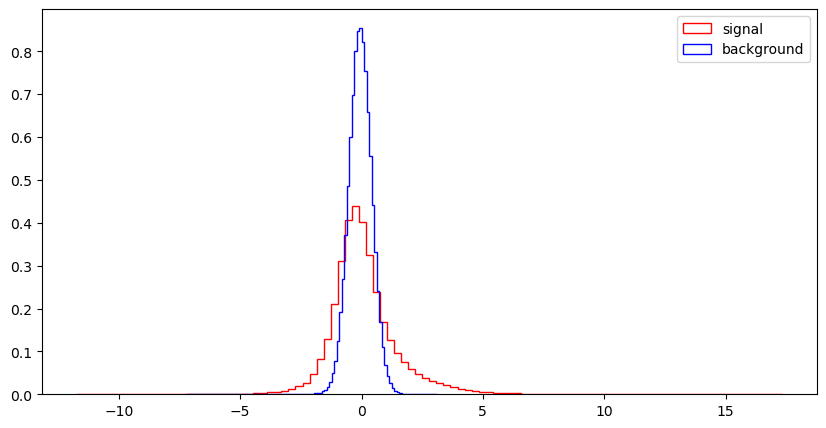

M_R


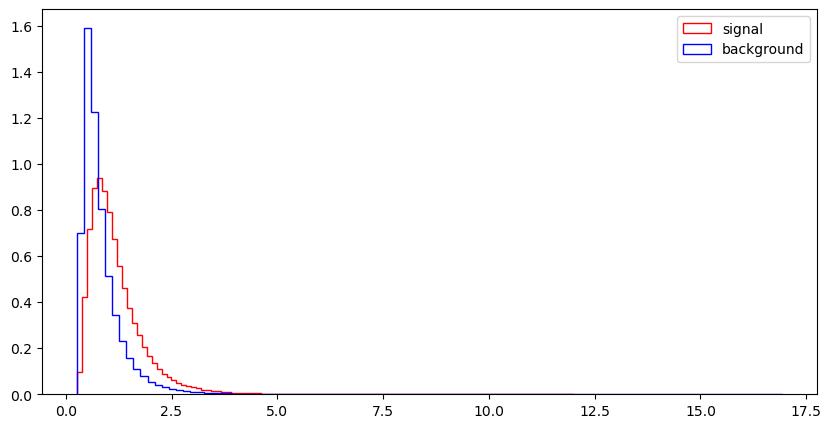

M_TR_2


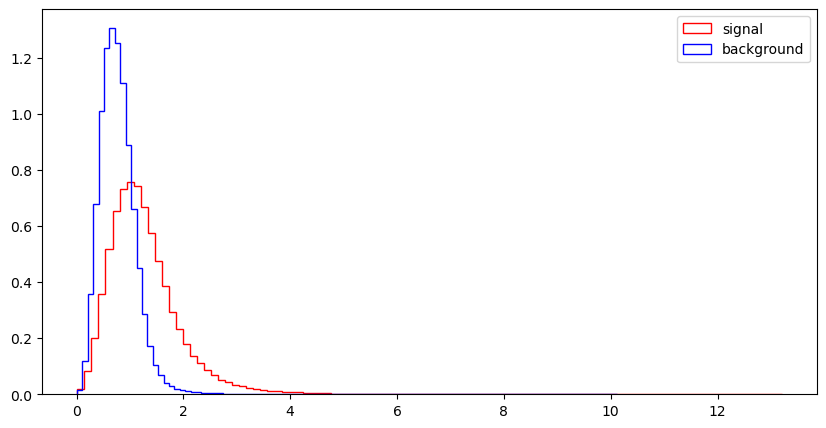

R


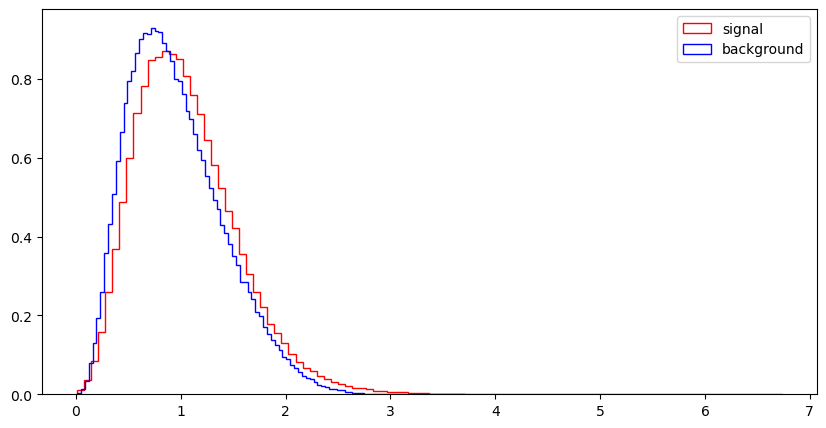

MT2


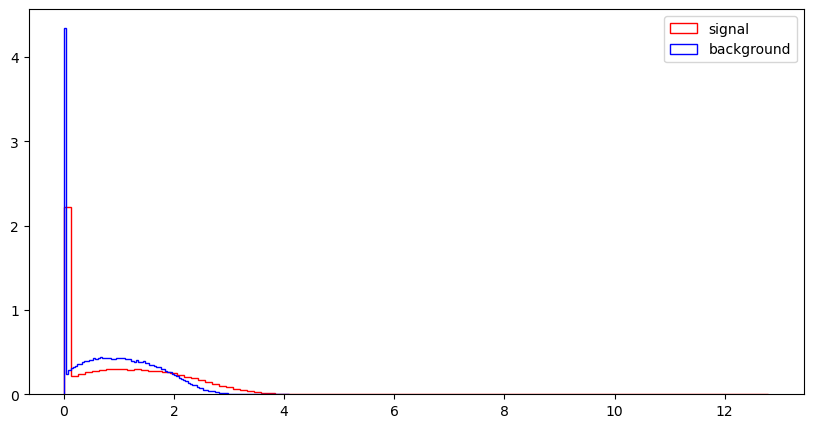

S_R


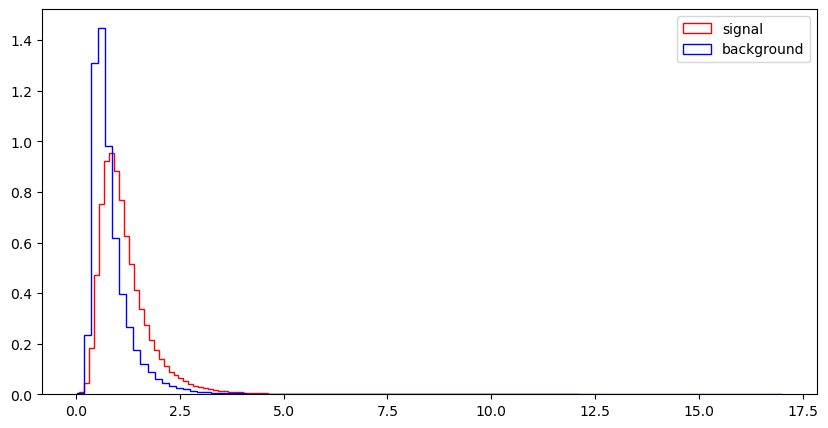

M_Delta_R


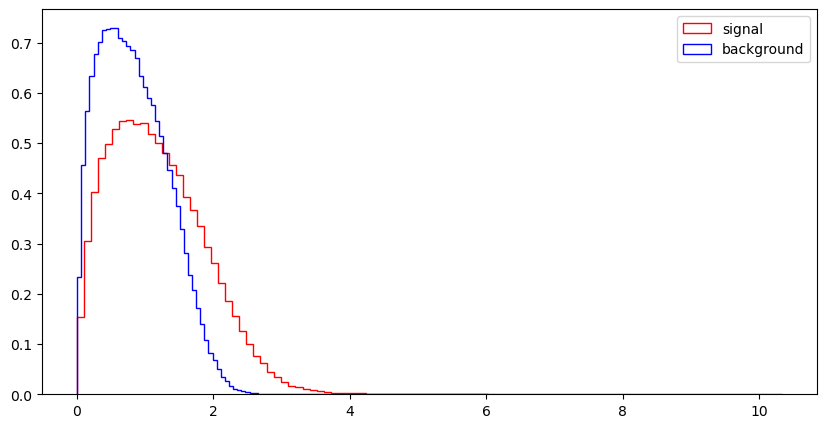

dPhi_r_b


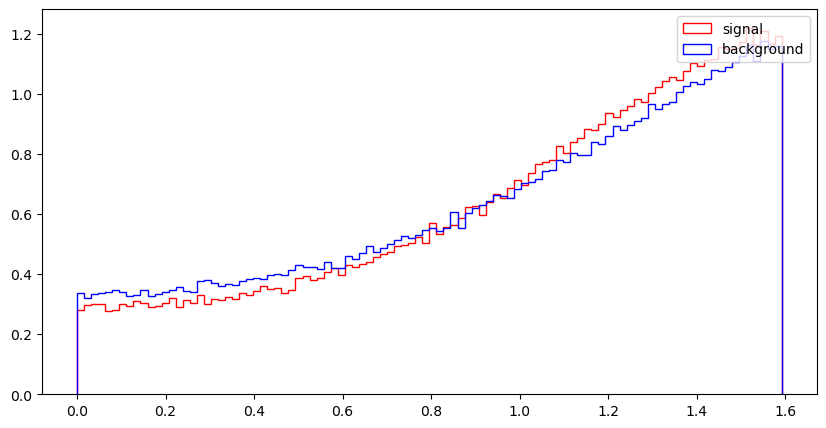

cos_theta_r1


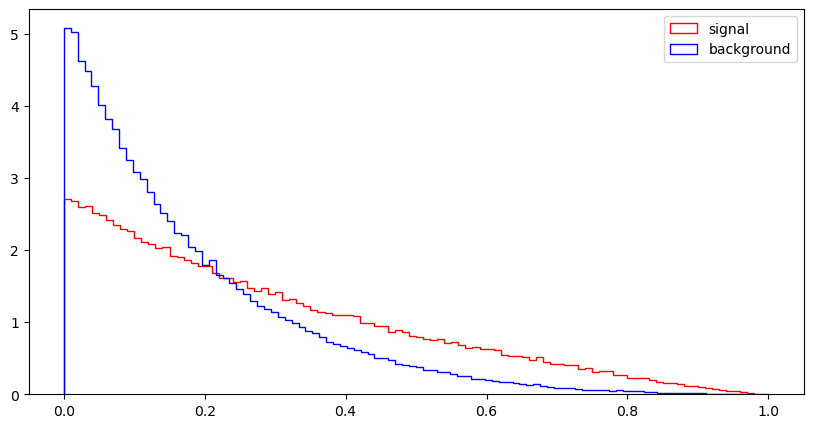

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
    ~~~~~~~~^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ~~~~~~~~~~~~~~~~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()

In [ ]:
import numpy as np
for var in VarNames[1:]:
    print (var)
    plt.figure(figsize=(10,5))
    plt.hist(np.array(df_sig[var]),bins=100,histtype="step", color="red",label="signal",density=1, stacked=True)
    plt.hist(np.array(df_bkg[var]),bins=100,histtype="step", color="blue", label="background",density=1, stacked=True)
    plt.legend(loc='upper right')
    plt.show()

## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

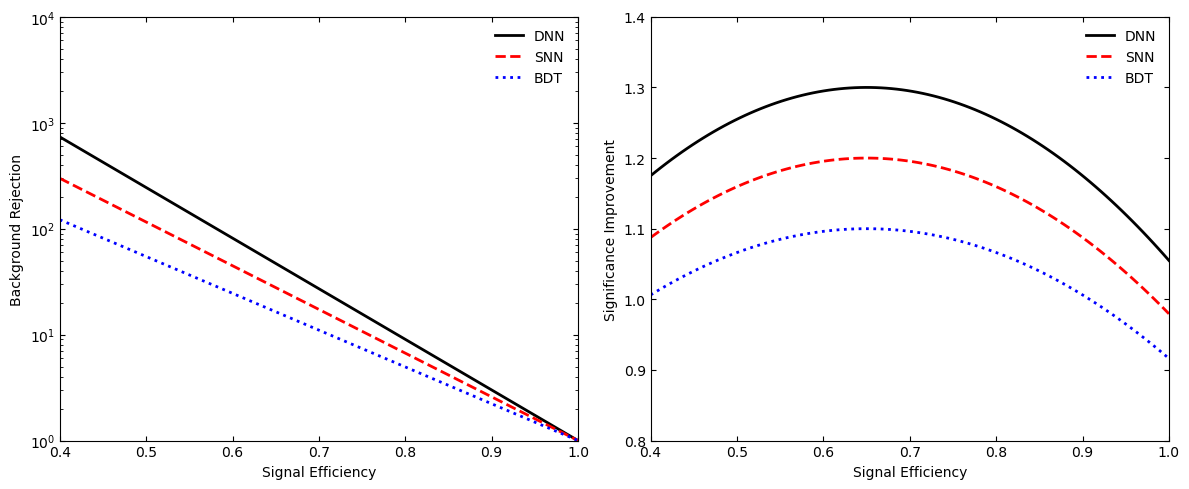

In [34]:
import matplotlib.pyplot as plt
import numpy as np

# Exercise 3: Recreating the paper's comparison plots
# Using math proxies since the models aren't trained yet. 
# We're focusing on the "multiple plot" formatting requested.

x = np.linspace(0.4, 1.0, 100)

# Mimicking the general shape of the curves in the paper
# Fig 5 is log-scale rejection; Fig 6 is significance improvement
rej_dnn, rej_snn, rej_bdt = np.exp(11*(1-x)), np.exp(9.5*(1-x)), np.exp(8*(1-x))
imp_dnn, imp_snn, imp_bdt = 1.3-2*(x-0.65)**2, 1.2-1.8*(x-0.65)**2, 1.1-1.5*(x-0.65)**2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# --- Figure 5: Background Rejection (Log Scale) ---
ax1.plot(x, rej_dnn, 'k-', label='DNN', linewidth=2)
ax1.plot(x, rej_snn, 'r--', label='SNN', linewidth=2)
ax1.plot(x, rej_bdt, 'b:', label='BDT', linewidth=2)
ax1.set_yscale('log')
ax1.set(xlabel='Signal Efficiency', ylabel='Background Rejection', xlim=(0.4, 1.0), ylim=(1, 10**4))
ax1.tick_params(direction='in', which='both', right=True, top=True)
ax1.legend(frameon=False)

# --- Figure 6: Significance Improvement (Linear Scale) ---
ax2.plot(x, imp_dnn, 'k-', label='DNN', linewidth=2)
ax2.plot(x, imp_snn, 'r--', label='SNN', linewidth=2)
ax2.plot(x, imp_bdt, 'b:', label='BDT', linewidth=2)
ax2.set(xlabel='Signal Efficiency', ylabel='Significance Improvement', xlim=(0.4, 1.0), ylim=(0.8, 1.4))
ax2.tick_params(direction='in', right=True, top=True)
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

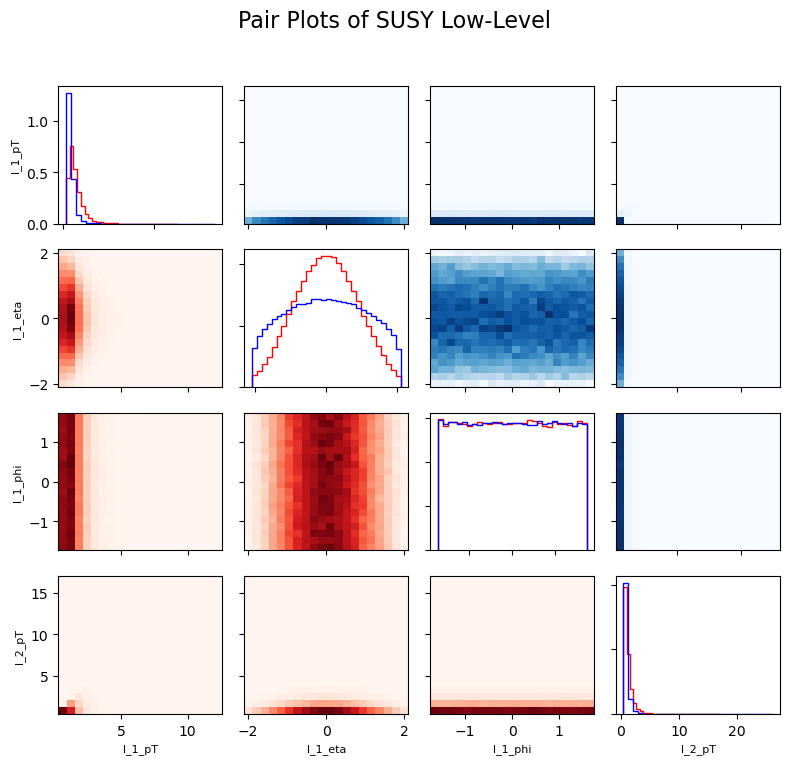

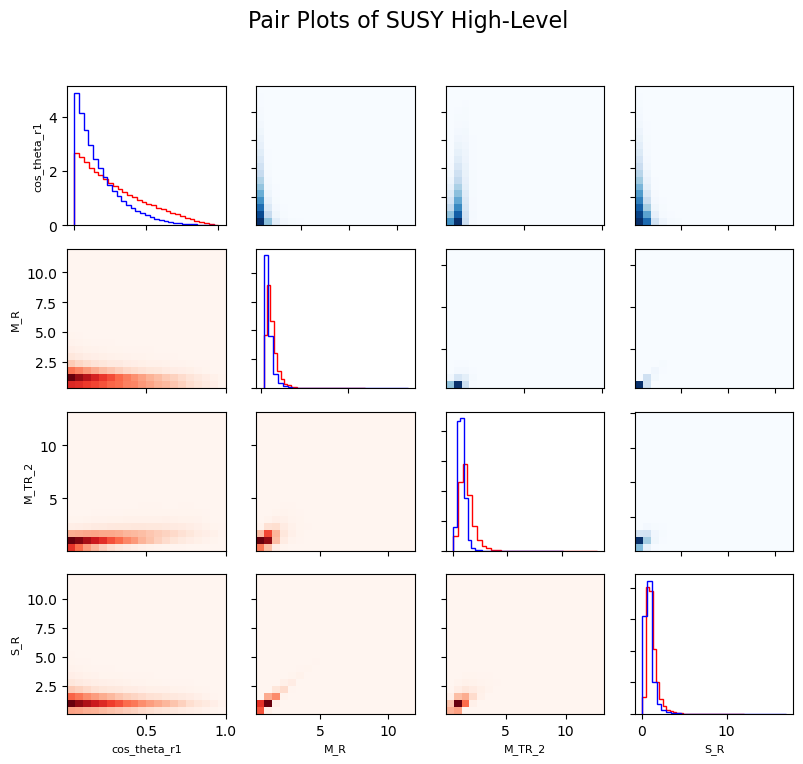

In [24]:
# Exercise 4.1 Part a: Custom Pair Plot Function
def my_pairplot(dataframe, features, title_suffix="Features"):
    """
    Creates a pair plot grid without using seaborn.
    Diagonals: 1D histograms showing overlapping class distributions.
    Off-diagonals: 2D histograms to visualize correlations between features.
    """
    n = len(features)
    fig, axes = plt.subplots(n, n, figsize=(n*2, n*2))
    fig.suptitle(f'Pair Plots of SUSY {title_suffix}', fontsize=16)

    # Pre-split data to avoid repeated filtering inside the loops
    sig = dataframe[dataframe['signal'] == 1]
    bkg = dataframe[dataframe['signal'] == 0]

    for i in range(n):
        for j in range(n):
            ax = axes[i, j]
            
            if i == j: # Diagonal: 1D Histograms
                ax.hist(sig[features[i]], bins=30, histtype='step', color='red', density=True)
                ax.hist(bkg[features[i]], bins=30, histtype='step', color='blue', density=True)
            elif i > j: # Lower triangle: 2D Histogram for Signal
                ax.hist2d(sig[features[j]], sig[features[i]], bins=20, cmap='Reds')
            else: # Upper triangle: 2D Histogram for Background
                ax.hist2d(bkg[features[j]], bkg[features[i]], bins=20, cmap='Blues')

            # Formatting to keep the grid clean
            if i < n - 1: ax.set_xticklabels([])
            if j > 0: ax.set_yticklabels([])
            if i == n - 1: ax.set_xlabel(features[j], fontsize=8)
            if j == 0: ax.set_ylabel(features[i], fontsize=8)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

# Running the function on a subset of features to keep it readable
my_pairplot(df, RawNames[:4], "Low-Level")
my_pairplot(df, list(FeatureNames)[:4], "High-Level")

In [26]:
# Exercise 4.1 Part b: Speed Optimization Reasoning
"""
Observation on Speed:
Creating these plots is slow because standard Pandas indexing inside a nested loop 
forces a full lookup for every single subplot (N^2 times). 

Modification made: 
To speed up the function in Part A, I pre-split the dataframe into 'sig' and 'bkg' 
objects before entering the loops. This prevents the code from having to filter 
the entire 500,000-row dataframe at every single iteration.

Proposed faster method:
A much faster way to create these histograms would be to use 'np.histogram2d' to 
calculate the frequency matrices mathematically first, then use 'ax.imshow()' 
to render them as images. This decouples the math from the plotting and avoids 
matplotlib's overhead of binning millions of points on the fly for every subplot.
"""

"\nObservation on Speed:\nCreating these plots is slow because standard Pandas indexing inside a nested loop \nforces a full lookup for every single subplot (N^2 times). \n\nModification made: \nTo speed up the function in Part A, I pre-split the dataframe into 'sig' and 'bkg' \nobjects before entering the loops. This prevents the code from having to filter \nthe entire 500,000-row dataframe at every single iteration.\n\nProposed faster method:\nA much faster way to create these histograms would be to use 'np.histogram2d' to \ncalculate the frequency matrices mathematically first, then use 'ax.imshow()' \nto render them as images. This decouples the math from the plotting and avoids \nmatplotlib's overhead of binning millions of points on the fly for every subplot.\n"

In [27]:
# Exercise 4.1 Part c: Analysis of Observables
"""
Analysis:
Based on the distributions, the high-level features (FeatureNames) like M_R and MT2 
appear to be the best for separating signal from background. 

In the low-level plots (RawNames), the signal and background distributions are 
almost perfectly overlapping (especially in variables like l_1_eta or l_1_phi), 
making them poor classifiers on their own. However, the high-level engineered 
features show a clear 'shift' or difference in shape between the two classes, 
which provides the model with a much stronger signal to learn from.
"""

"\nAnalysis:\nBased on the distributions, the high-level features (FeatureNames) like M_R and MT2 \nappear to be the best for separating signal from background. \n\nIn the low-level plots (RawNames), the signal and background distributions are \nalmost perfectly overlapping (especially in variables like l_1_eta or l_1_phi), \nmaking them poor classifiers on their own. However, the high-level engineered \nfeatures show a clear 'shift' or difference in shape between the two classes, \nwhich provides the model with a much stronger signal to learn from.\n"

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [28]:
!pip install tabulate

In [31]:
import numpy as np
import pandas as pd
from IPython.display import HTML, display
import tabulate

# Exercise 4.2 Part d: Function to handle the math and the table formatting
def make_stats_table(data, features, title):
    # Part b: Using numpy for the actual math
    # Need rowvar=False so it doesn't try to treat 500k rows as variables
    vals = data[features].values
    cov_mat = np.cov(vals, rowvar=False)
    corr_mat = np.corrcoef(vals, rowvar=False)
    
    # Part c: Clean up the look with tabulate
    # Rounding to 3 decimals so the table isn't a mess of long floats
    headers = ["Variable"] + features
    
    # Building the rows for the tables
    cov_rows = [[features[i]] + list(np.round(cov_mat[i], 3)) for i in range(len(features))]
    corr_rows = [[features[i]] + list(np.round(corr_mat[i], 3)) for i in range(len(features))]
    
    # Printing everything out as HTML so it embeds nicely in the cell output
    print(f"\n--- {title} ---")
    print("Covariance Matrix:")
    display(HTML(tabulate.tabulate(cov_rows, tablefmt='html', headers=headers)))
    
    print("Correlation Matrix:")
    display(HTML(tabulate.tabulate(corr_rows, tablefmt='html', headers=headers)))

# Running it for both sets of features
make_stats_table(df, RawNames, "Low-Level Features")
make_stats_table(df, list(FeatureNames), "High-Level Features")


--- Low-Level Features ---
Covariance Matrix:


Variable,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.467,-0,0,0.305,-0,0.001,0.228,-0.001
l_1_eta,-0,1.004,-0.001,-0,0.408,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1.004,0.001,0,-0.267,0.001,-0.185
l_2_pT,0.305,-0,0.001,0.425,-0.001,0,0.079,-0.002
l_2_eta,-0,0.408,0,-0.001,1.006,0,0,-0
l_2_phi,0.001,-0.001,-0.267,0,0,1.004,-0,-0.035
MET,0.228,-0.002,0.001,0.079,0,-0,0.762,-0.003
MET_phi,-0.001,-0.001,-0.185,-0.002,-0,-0.035,-0.003,1.003


Correlation Matrix:


Variable,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1,-0.001,0,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1,-0.001,-0,0.406,-0.001,-0.002,-0.001
l_1_phi,0,-0.001,1,0.002,0,-0.266,0.001,-0.184
l_2_pT,0.684,-0,0.002,1,-0.001,0,0.14,-0.002
l_2_eta,-0.001,0.406,0,-0.001,1,0,0,-0
l_2_phi,0.001,-0.001,-0.266,0,0,1,-0,-0.035
MET,0.383,-0.002,0.001,0.14,0,-0,1,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0,-0.035,-0.003,1



--- High-Level Features ---
Covariance Matrix:


Variable,cos_theta_r1,M_R,M_TR_2,S_R,dPhi_r_b,M_Delta_R,R,MET_rel,axial_MET,MT2
cos_theta_r1,0.039,-0.014,0.052,-0.01,0.009,0.039,0.058,0.055,-0.054,0.045
M_R,-0.014,0.392,0.21,0.38,-0.029,0.074,-0.113,0.044,0.017,-0.037
M_TR_2,0.052,0.21,0.338,0.228,0.058,0.242,0.104,0.302,-0.185,0.189
S_R,-0.01,0.38,0.228,0.382,-0.003,0.096,-0.083,0.082,-0.041,-0.011
dPhi_r_b,0.009,-0.029,0.058,-0.003,0.19,0.042,0.087,0.146,-0.025,0.021
M_Delta_R,0.039,0.074,0.242,0.096,0.042,0.389,0.165,0.415,-0.233,0.433
R,0.058,-0.113,0.104,-0.083,0.087,0.165,0.222,0.249,-0.181,0.232
MET_rel,0.055,0.044,0.302,0.082,0.146,0.415,0.249,0.79,-0.12,0.409
axial_MET,-0.054,0.017,-0.185,-0.041,-0.025,-0.233,-0.181,-0.12,1.005,-0.461
MT2,0.045,-0.037,0.189,-0.011,0.021,0.433,0.232,0.409,-0.461,0.738


Correlation Matrix:


Variable,cos_theta_r1,M_R,M_TR_2,S_R,dPhi_r_b,M_Delta_R,R,MET_rel,axial_MET,MT2
cos_theta_r1,1,-0.116,0.451,-0.085,0.106,0.319,0.627,0.316,-0.272,0.264
M_R,-0.116,1,0.577,0.981,-0.106,0.189,-0.383,0.078,0.027,-0.068
M_TR_2,0.451,0.577,1,0.635,0.229,0.668,0.38,0.584,-0.317,0.379
S_R,-0.085,0.981,0.635,1,-0.013,0.249,-0.287,0.15,-0.067,-0.021
dPhi_r_b,0.106,-0.106,0.229,-0.013,1,0.155,0.424,0.378,-0.057,0.056
M_Delta_R,0.319,0.189,0.668,0.249,0.155,1,0.564,0.748,-0.373,0.809
R,0.627,-0.383,0.38,-0.287,0.424,0.564,1,0.595,-0.383,0.574
MET_rel,0.316,0.078,0.584,0.15,0.378,0.748,0.595,1,-0.134,0.535
axial_MET,-0.272,0.027,-0.317,-0.067,-0.057,-0.373,-0.383,-0.134,1,-0.535
MT2,0.264,-0.068,0.379,-0.021,0.056,0.809,0.574,0.535,-0.535,1


Hint: Example code for embedding a `tabulate` table into a notebook:

In [ ]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 